# Part 1: Data Cleaning and Enrichment

## 1. Imports

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import importlib

# %load_ext autoreload
# %autoreload 2

# Automatically find the project root (where src/ lives)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added to sys.path:", PROJECT_ROOT)

import src.data_cleaning
import src.feature_engineering
importlib.reload(src.data_cleaning)
importlib.reload(src.feature_engineering)
from src.feature_engineering import add_history_features
from src.simulation_engine import simulate
print("Successfully imported  add_history_features")
# Force a reload of the module to pick up the new function
import src.data_cleaning
importlib.reload(src.data_cleaning)
from src.data_cleaning import clean_data,handle_missing_values
from src.risk_model import train_risk_model, apply_risk_scoring

print("Successfully imported clean_data")

Project root added to sys.path: d:\Users\Hp\loan-risk-analysis
Successfully imported  add_history_features
Successfully imported clean_data


## 2. Data Loading

In [38]:
df = pd.read_csv("../data/loan_history.csv")
df.head()

,CustomerID,MonthlySalary,LoanAmount,DisbursementDate,DueDate,ActualRepaymentDate,PastDue30Days
0,C001,2500,500,2025-01-05,2025-02-04,2025-01-19,0
1,C002,3200,700,2025-01-10,2025-02-09,2025-02-05,1
2,C001,2500,400,2025-02-01,2025-03-03,2025-02-15,0
3,C003,2800,600,2025-01-15,2025-02-14,2025-02-10,1
4,C004,4000,1000,2025-02-05,2025-03-07,2025-02-19,0


## 3. Data Inspection

In [39]:
# Check DataFrame structure and summary
df.info()

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Check for duplicate rows & remove them
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_count)
df = df.drop_duplicates()
# Handle missing values: remove them and save to a separate CSV
missing_csv_path = os.path.join(PROJECT_ROOT, "data/missing_values.csv")
df = handle_missing_values(df, missing_csv_path)


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   CustomerID           14 non-null     str  
 1   MonthlySalary        14 non-null     int64
 2   LoanAmount           14 non-null     int64
 3   DisbursementDate     14 non-null     str  
 4   DueDate              14 non-null     str  
 5   ActualRepaymentDate  14 non-null     str  
 6   PastDue30Days        14 non-null     int64
dtypes: int64(3), str(4)
memory usage: 916.0 bytes
Missing Values:
 CustomerID             0
MonthlySalary          0
LoanAmount             0
DisbursementDate       0
DueDate                0
ActualRepaymentDate    0
PastDue30Days          0
dtype: int64
Number of Duplicate Rows: 0
No missing values found. Created empty file with headers at: d:\Users\Hp\loan-risk-analysis\data/missing_values.csv


## 4. Data Cleaning (Dates & Missing Values)

In [40]:
df = pd.read_csv(os.path.join(PROJECT_ROOT, "data/loan_history.csv"))
df = clean_data(df)
df.head()

,CustomerID,MonthlySalary,LoanAmount,DisbursementDate,DueDate,ActualRepaymentDate,PastDue30Days,LatePayment
0,C001,2500,500,2025-01-05,2025-02-04,2025-01-19,0,False
1,C002,3200,700,2025-01-10,2025-02-09,2025-02-05,1,True
2,C001,2500,400,2025-02-01,2025-03-03,2025-02-15,0,False
3,C003,2800,600,2025-01-15,2025-02-14,2025-02-10,1,True
4,C004,4000,1000,2025-02-05,2025-03-07,2025-02-19,0,False


## 5. Late Payment Flagging

In [41]:
# Create a new column to indicate late payments
df['LatePayment'] = df['PastDue30Days'] == 1  # True if repayment is overdue by 30 days or more
print("\nUpdated DataFrame with Late Payment Status:")
print(df[['CustomerID', 'PastDue30Days', 'LatePayment']].head())


Updated DataFrame with Late Payment Status:
  CustomerID  PastDue30Days  LatePayment
0       C001              0        False
1       C002              1         True
2       C001              0        False
3       C003              1         True
4       C004              0        False


## 6. Customer History (Previous Loans & Risk Flags)

In [42]:
# Apply the historical feature engineering from the src module
df = add_history_features(df)

df.head()


,CustomerID,MonthlySalary,LoanAmount,DisbursementDate,DueDate,ActualRepaymentDate,PastDue30Days,LatePayment,previous_loans,previous_on_time,ever_past_due
0,C001,2500,500,2025-01-05,2025-02-04,2025-01-19,0,False,0,0,0
1,C001,2500,400,2025-02-01,2025-03-03,2025-02-15,0,False,1,1,0
2,C001,2500,450,2025-03-10,2025-04-09,2025-04-05,1,True,2,2,0
3,C002,3200,700,2025-01-10,2025-02-09,2025-02-05,1,True,0,0,0
4,C002,3200,800,2025-03-01,2025-03-31,2025-03-14,0,False,1,0,1


## 7. Saving Cleaned Data

In [43]:
# Save the cleaned and enriched loan history data
df.to_csv("../data/clean_loan_history.csv", index=False)
# Reset index for further analysis
df = df.sort_values(['CustomerID', 'DisbursementDate']).reset_index(drop=True)

# Part 2: Simulation Results and Risk Analytics

## 8. Loading Simulation Results

In [44]:
# Load simulation result file (assuming simulation_engine.py has been run)
df_sim = pd.read_csv("../data/simulation_results.csv")
df_sim.head()

,CustomerID,MonthlySalary,LoanAmount,DisbursementDate,DueDate,ActualRepaymentDate,PastDue30Days,LatePayment,previous_loans,on_time,previous_on_time,ever_30dpd,Multiplier,AllowedLimit,Approved
0,C001,2500,500,2025-01-05,2025-02-04,2025-01-19,0,False,0,True,0,False,0.5,1250.0,True
1,C001,2500,400,2025-02-01,2025-03-03,2025-02-15,0,False,1,True,1,False,1.0,2500.0,True
2,C001,2500,450,2025-03-10,2025-04-09,2025-04-05,1,True,2,False,2,True,1.5,3750.0,True
3,C002,3200,700,2025-01-10,2025-02-09,2025-02-05,1,True,0,False,0,True,0.5,1600.0,True
4,C002,3200,800,2025-03-01,2025-03-31,2025-03-14,0,False,1,True,0,True,0.5,1600.0,True


## 9. Risk Classification

In [45]:
df_sim = simulate(df)
# 2. Sort and reset the index
df_sim = df_sim.sort_values(['CustomerID', 'DisbursementDate']).reset_index(drop=True)
# 3. Add the Classification Logic
def classify(row):
    # Rule Reject? (Approved = False)
    # Actual Good? (LatePayment = False)
    if not row["Approved"] and row["LatePayment"]:
        return "True Positive"   # Correctly caught a bad loan
    elif not row["Approved"] and not row["LatePayment"]:
        return "False Positive"  # Accidentally rejected a good loan
    elif row["Approved"] and row["LatePayment"]:
        return "False Negative"  # Approved a bad loan
    else:
        return "True Negative"   # Approved a good loan
df_sim["Classification"] = df_sim.apply(classify, axis=1)
# Review the top results and the summary
print("Strategy Performance Summary:")
print(df_sim["Classification"].value_counts())
df_sim.head()

Strategy Performance Summary:
Classification
True Negative     7
False Negative    7
Name: count, dtype: int64


,CustomerID,MonthlySalary,LoanAmount,DisbursementDate,DueDate,ActualRepaymentDate,PastDue30Days,LatePayment,previous_loans,previous_on_time,ever_past_due,Multiplier,AllowedLimit,Approved,Classification
0,C001,2500,500,2025-01-05,2025-02-04,2025-01-19,0,False,0,0,0,0.5,1250.0,True,True Negative
1,C001,2500,400,2025-02-01,2025-03-03,2025-02-15,0,False,1,1,0,1.0,2500.0,True,True Negative
2,C001,2500,450,2025-03-10,2025-04-09,2025-04-05,1,True,2,2,0,1.5,3750.0,True,False Negative
3,C002,3200,700,2025-01-10,2025-02-09,2025-02-05,1,True,0,0,0,0.5,1600.0,True,False Negative
4,C002,3200,800,2025-03-01,2025-03-31,2025-03-14,0,False,1,0,1,0.5,1600.0,True,True Negative


## 10. Risk Analytics

In [46]:
# Calculate Mitigated Risk
mitigated_risk = df_sim[df_sim["Classification"] == "True Positive"]["LoanAmount"].sum()
print("Mitigated Risk:", mitigated_risk)

Mitigated Risk: 0


## 11. Visualization

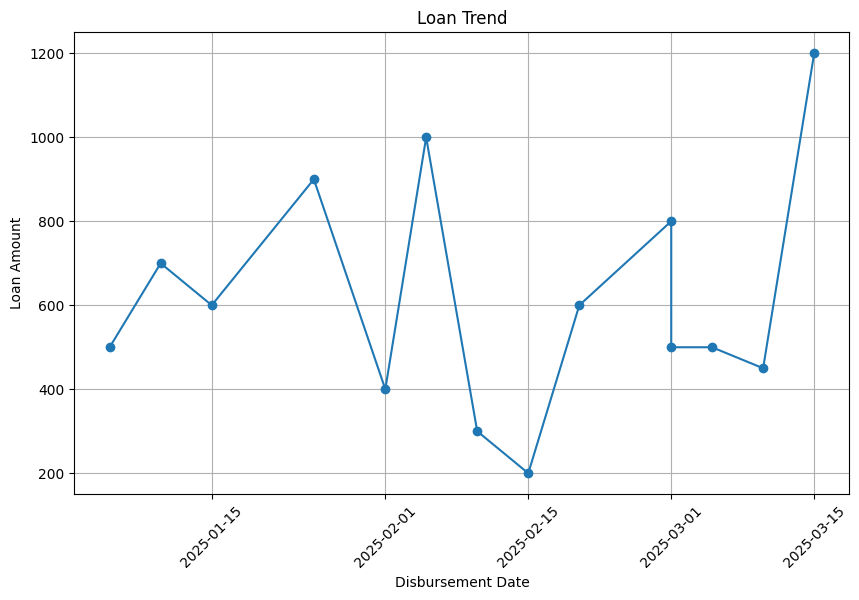

In [47]:
# Visualization of Loan Amount Trend
df_sim["DisbursementDate"] = pd.to_datetime(df_sim["DisbursementDate"])
df_sim = df_sim.sort_values("DisbursementDate")

plt.figure(figsize=(10, 6))
plt.plot(df_sim["DisbursementDate"], df_sim["LoanAmount"], marker='o')
plt.xticks(rotation=45)
plt.title("Loan Trend")
plt.xlabel("Disbursement Date")
plt.ylabel("Loan Amount")
plt.grid(True)
plt.show()

3,logic rergression scoring


In [48]:
# 1. Train and Score
model = train_risk_model(df_sim)
df_scored = apply_risk_scoring(df_sim, model)

# 2. Save it back to your data folder
df_scored.to_csv("../data/loan_risk_results.csv", index=False)


Logistic Regression Model trained on 14 rows.
